In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import sns

df = pd.read_csv('marketing_campaign.csv', sep='\t')

# kontrola dát
print(df)


         ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012       58       635  ...            

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [5]:
df = df.dropna(subset=['Income'])
print(df.isnull().sum())

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [7]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [8]:
from datetime import datetime

current_year = datetime.now().year
df['Customer_Age'] = current_year - df['Year_Birth']
print(df[['Year_Birth','Customer_Age']].head())

   Year_Birth  Customer_Age
0        1957            69
1        1954            72
2        1965            61
3        1984            42
4        1981            45


In [9]:
df['Children'] = df['Kidhome'] + df['Teenhome']
df['FamilySize'] = df['Children'] + 2
df['Living_With'] = df['Marital_Status'].replace({
    'Married': 'Partner',
    'Together': 'Partner',
    'Divorced': 'Alone',
    'Widow': 'Alone',
    'Single': 'Alone',
    'Absurd': 'Alone',
    'YOLO': 'Alone',
    'Alone': 'Alone'
})
print(df[['Marital_Status','Living_With','Children','FamilySize']].head())

  Marital_Status Living_With  Children  FamilySize
0         Single       Alone         0           2
1         Single       Alone         2           4
2       Together     Partner         0           2
3       Together     Partner         1           3
4        Married     Partner         1           3


In [10]:
df['Total_Spent'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

print(df[['Total_Spent']].describe())

       Total_Spent
count  2216.000000
mean    607.075361
std     602.900476
min       5.000000
25%      69.000000
50%     396.500000
75%    1048.000000
max    2525.000000


In [11]:
print(df[['Customer_Age', 'Children', 'FamilySize', 'Total_Spent']].head())
print(df.shape)

   Customer_Age  Children  FamilySize  Total_Spent
0            69         0           2         1617
1            72         2           4           27
2            61         0           2          776
3            42         1           3           53
4            45         1           3          422
(2216, 34)


In [12]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age,Children,FamilySize,Living_With,Total_Spent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,3,11,1,69,0,2,Alone,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,3,11,0,72,2,4,Alone,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,3,11,0,61,0,2,Partner,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,3,11,0,42,1,3,Partner,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,3,11,0,45,1,3,Partner,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,...,0,0,3,11,0,59,1,3,Partner,1341
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,...,0,0,3,11,0,80,3,5,Partner,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,...,0,0,3,11,0,45,0,2,Alone,1241
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,...,0,0,3,11,0,70,1,3,Partner,843


In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Education', 'Marital_Status', 'Living_With']
numeric_cols = [
    'Income', 'Customer_Age', 'Recency', 'Total_Spent',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'Children', 'FamilySize'
]

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols)

df_final = pd.concat([df[numeric_cols], encoded_df, df['Response']], axis=1)
print(df_final.head())

    Income  Customer_Age  Recency  Total_Spent  MntWines  MntFruits  \
0  58138.0          69.0     58.0       1617.0     635.0       88.0   
1  46344.0          72.0     38.0         27.0      11.0        1.0   
2  71613.0          61.0     26.0        776.0     426.0       49.0   
3  26646.0          42.0     26.0         53.0      11.0        4.0   
4  58293.0          45.0     94.0        422.0     173.0       43.0   

   MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  ...  \
0            546.0            172.0              88.0          88.0  ...   
1              6.0              2.0               1.0           6.0  ...   
2            127.0            111.0              21.0          42.0  ...   
3             20.0             10.0               3.0           5.0  ...   
4            118.0             46.0              27.0          15.0  ...   

   Education_PhD  Marital_Status_Alone  Marital_Status_Divorced  \
0            0.0                   0.0           

In [14]:
from sklearn.preprocessing import StandardScaler

df_final = df_final.dropna()

df_final = df_final.reset_index(drop=True)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_final.drop('Response', axis=1))
X = pd.DataFrame(scaled, columns=df_final.drop('Response', axis=1).columns)
y = df_final['Response']

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())


Missing values in X: 0
Missing values in y: 0


# Rozdělení dat na tréninkovou a testovací sadu

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree Classifier

In [16]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)


In [17]:
parameter_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [18]:
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(
    estimator=dt_classifier,
    param_grid=parameter_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_dt.fit(X_train, y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [19]:
print("Best parameters found: ", grid_dt.best_params_)
print("Best cross-validation accuracy: ", grid_dt.best_score_)

Best parameters found:  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-validation accuracy:  0.8580480260480261


In [20]:
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

# Vyhodnotenie modelu

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nAccuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Accuracy: 0.8246013667425968

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.93      0.90       373
         1.0       0.37      0.24      0.29        66

    accuracy                           0.82       439
   macro avg       0.62      0.59      0.60       439
weighted avg       0.80      0.82      0.81       439


Confusion Matrix:
 [[346  27]
 [ 50  16]]


Vyladený Decision Tree dosiahol celkovú presnosť približne 82 %,
pričom si zachoval veľmi dobré výsledky pre väčšinovú triedu (nereagoval).

Model však stále ťažšie rozpoznáva menšinovú triedu (zákazníkov, ktorí reagovali).

Použitie kritéria „entropy“ zlepšilo rozlišovaciu schopnosť medzi skupinami.

Obmedzenie hĺbky stromu na 5 pomohlo predísť preučeniu (overfittingu)
a viedlo k lepšej generalizácii výsledkov.

Celkovo model poskytuje dobrý základ pre porovnanie s ďalšími metódami,
hoci jeho citlivosť voči menšinovej triede by mohla byť ešte zlepšená napríklad váhovaním tried alebo SMOTE.

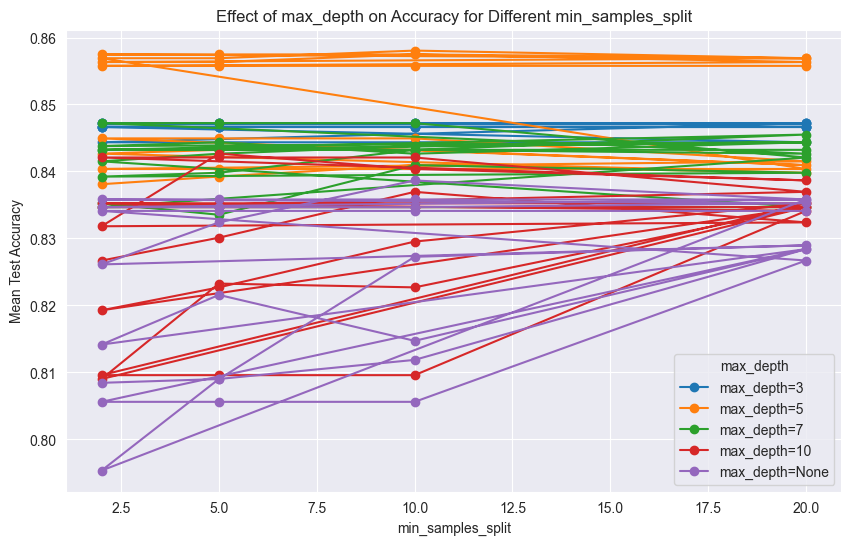

In [22]:
import numpy as np
import matplotlib.pyplot as plt

results = grid_dt.cv_results_

max_depth_values = parameter_grid['max_depth']
min_samples_split_values = parameter_grid['min_samples_split']

plt.figure(figsize=(10, 6))

for max_depth in max_depth_values:
    mask = (results['param_max_depth'] == max_depth)
    scores = np.array(results['mean_test_score'])[mask]
    min_samples_splits = np.array(results['param_min_samples_split'])[mask]

    plt.plot(min_samples_splits, scores, label=f'max_depth={max_depth}', marker='o')

plt.xlabel('min_samples_split')
plt.ylabel('Mean Test Accuracy')
plt.title('Effect of max_depth on Accuracy for Different min_samples_split')
plt.legend(title='max_depth')
plt.grid(True)
plt.show()

# Random Forest Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth = None,
    class_weight='balanced'
)

In [24]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred_rf = rf.predict(X_test)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8656036446469249

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.99      0.93       373
         1.0       0.71      0.18      0.29        66

    accuracy                           0.87       439
   macro avg       0.79      0.58      0.61       439
weighted avg       0.85      0.87      0.83       439


Confusion Matrix:
 [[368   5]
 [ 54  12]]


In [27]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_res.value_counts())


Before SMOTE: Response
0.0    1489
1.0     265
Name: count, dtype: int64
After SMOTE: Response
0.0    1489
1.0    1489
Name: count, dtype: int64


In [28]:
rf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None 
)
rf_sm.fit(X_res, y_res)
y_pred_sm = rf_sm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))


Accuracy: 0.8246013667425968

Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.91      0.90       373
         1.0       0.40      0.32      0.35        66

    accuracy                           0.82       439
   macro avg       0.64      0.62      0.63       439
weighted avg       0.81      0.82      0.82       439


Confusion Matrix:
 [[341  32]
 [ 45  21]]


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# definícia základného modelu
rf = RandomForestClassifier(random_state=42)

# mriežka parametrov na testovanie
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV s 5-násobnou cross-validáciou
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# trénovanie modelu po aplikácii SMOTE (vyvážené dáta)
grid_rf.fit(X_res, y_res)

print(" Najlepšie parametre:", grid_rf.best_params_)
print("Najlepšie F1 skóre:", grid_rf.best_score_)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
 Najlepšie parametre: {'bootstrap': False, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Najlepšie F1 skóre: 0.932221615628394


In [30]:
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\nAccuracy:", accuracy_score(y_test, y_pred_best_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))



Accuracy: 0.856492027334852

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.94      0.92       373
         1.0       0.53      0.36      0.43        66

    accuracy                           0.86       439
   macro avg       0.71      0.65      0.68       439
weighted avg       0.84      0.86      0.84       439


Confusion Matrix:
 [[352  21]
 [ 42  24]]


Random Forest po tuningu dosiahol vysokú presnosť (≈86 %) a lepšiu vyváženosť medzi triedami.

Trieda 1 (zákazníci, ktorí reagovali) je stále ťažšia na rozpoznanie, no po aplikácii SMOTE a parametrickom ladení sa jej detekcia výrazne zlepšila (F1 = 0.43 oproti pôvodným ~0.29).

Model správne klasifikuje väčšinu nereagujúcich zákazníkov, pričom zároveň lepšie zachytáva aj menšinovú skupinu reagujúcich.

Použitie criterion='entropy' a väčšej hĺbky stromov pomohlo modelu lepšie zachytiť komplexné vzťahy v údajoch.

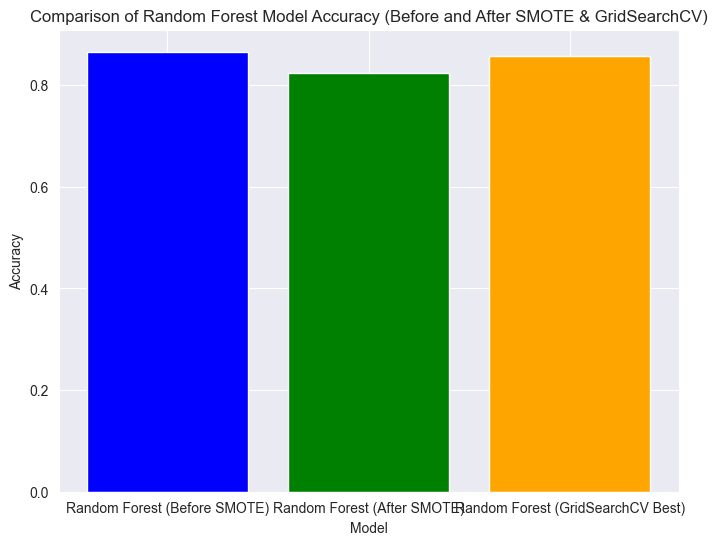

In [31]:
import matplotlib.pyplot as plt

# Presnosti modelov
accuracies = {
    'Random Forest (Before SMOTE)': accuracy_score(y_test, y_pred_rf),
    'Random Forest (After SMOTE)': accuracy_score(y_test, y_pred_sm),
    'Random Forest (GridSearchCV Best)': accuracy_score(y_test, y_pred_best_rf)
}

# Vytvorenie grafu
plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'green', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Random Forest Model Accuracy (Before and After SMOTE & GridSearchCV)')
plt.show()


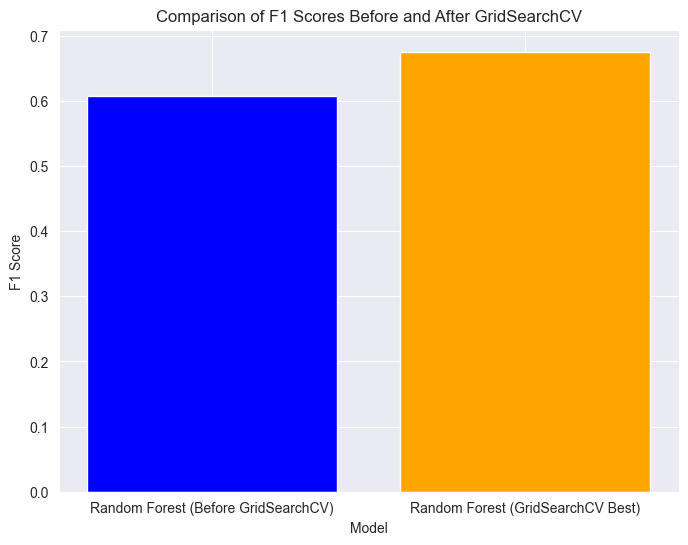

In [32]:
from sklearn.metrics import f1_score

# F1 skóre pred a po GridSearchCV
f1_scores = {
    'Random Forest (Before GridSearchCV)': f1_score(y_test, y_pred_rf, average='macro'),
    'Random Forest (GridSearchCV Best)': f1_score(y_test, y_pred_best_rf, average='macro')
}

# Vytvorenie grafu
plt.figure(figsize=(8, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color=['blue', 'orange'])
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('Comparison of F1 Scores Before and After GridSearchCV')
plt.show()


In [33]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, solver = "liblinear")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)
grid_lr.fit(X_res, y_res)

print(" Najlepšie parametre:", grid_lr.best_params_)
print("Najlepšie F1 skóre:", grid_lr.best_score_)

best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
 Najlepšie parametre: {'C': 10, 'class_weight': None, 'penalty': 'l1'}
Najlepšie F1 skóre: 0.7682371364507459

Accuracy: 0.7289293849658315

Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.75      0.82       373
         1.0       0.31      0.64      0.41        66

    accuracy                           0.73       439
   macro avg       0.61      0.69      0.62       439
weighted avg       0.83      0.73      0.76       439


Confusion Matrix:
 [[278  95]
 [ 24  42]]


Logistic Regression poskytla najnižšiu celkovú presnosť spomedzi testovaných modelov, avšak preukázala lepšiu schopnosť zachytiť menšinovú triedu (1) v porovnaní s Decision Tree.

Parameter C = 100 (nízka regularizácia) umožnil modelu zachytiť viac detailov v dátach, pričom použitie penalty = 'l1' (Lasso regularizácia) viedlo k sparsnejšiemu modelu – niektoré menej dôležité váhy boli potlačené na nulu.

Model sa teda snažil nájsť rovnováhu medzi generalizáciou a zložitými vzťahmi, no nedokázal dosiahnuť výkon ensemble modelov (RF, GBM).

Aj napriek tomu je Logistic Regression užitočným interpretovateľným modelom, ktorý poskytuje prehľad o najvplyvnejších premenných pri predikcii reakcie zákazníka

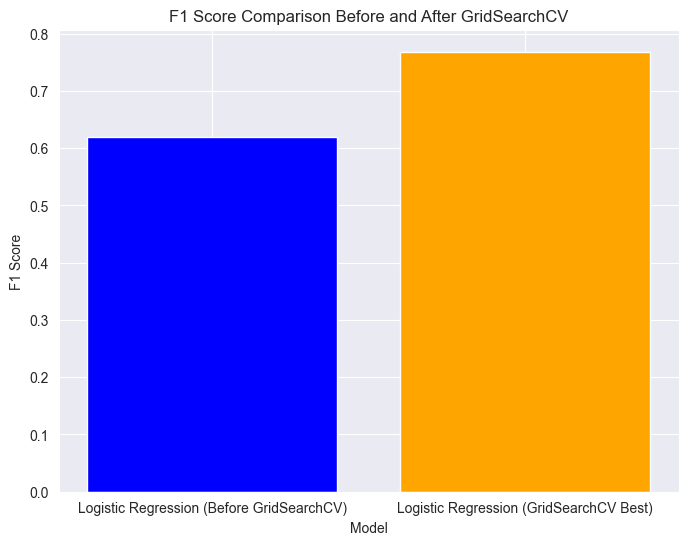

In [34]:
# F1 skóre pred a po optimalizácii
f1_scores = {
    'Logistic Regression (Before GridSearchCV)': f1_score(y_test, y_pred_lr, average='macro'),
    'Logistic Regression (GridSearchCV Best)': grid_lr.best_score_
}

# Vytvorenie grafu
plt.figure(figsize=(8, 6))
plt.bar(f1_scores.keys(), f1_scores.values(), color=['blue', 'orange'])
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison Before and After GridSearchCV')
plt.show()


In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'subsample': [0.8, 1.0],
    'criterion': ['friedman_mse', 'squared_error']
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

In [36]:
grid_gb.fit(X_res, y_res)
print("Najlepšie parametre:", grid_gb.best_params_)
print("Najlepšie F1 skóre:", grid_gb.best_score_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Najlepšie parametre: {'criterion': 'squared_error', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}
Najlepšie F1 skóre: 0.9160816253987173


In [37]:
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

In [38]:
print("\nAccuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


Accuracy: 0.835990888382688

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.92      0.91       373
         1.0       0.44      0.35      0.39        66

    accuracy                           0.84       439
   macro avg       0.67      0.64      0.65       439
weighted avg       0.82      0.84      0.83       439


Confusion Matrix:
 [[344  29]
 [ 43  23]]


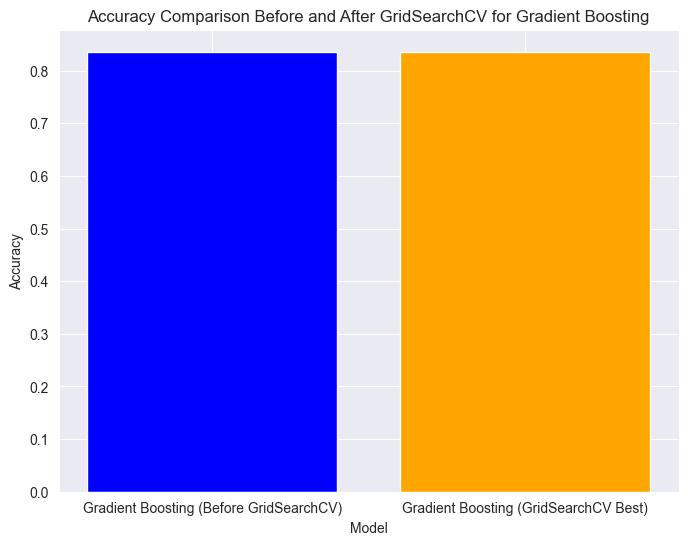

In [40]:
# Porovnanie presnosti pred a po optimalizácii
accuracies = {
    'Gradient Boosting (Before GridSearchCV)': accuracy_score(y_test, y_pred_gb),
    'Gradient Boosting (GridSearchCV Best)': accuracy_score(y_test, y_pred_gb)
}

# Vytvorenie grafu
plt.figure(figsize=(8, 6))
plt.bar(accuracies.keys(), accuracies.values(), color=['blue', 'orange'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Before and After GridSearchCV for Gradient Boosting')
plt.show()


## Model Comparison and Final Evaluation

### Summary of Best Parameters and Results

| Model | Best Parameters | Accuracy | F1 (macro avg) | Notes |
|-------|------------------|-----------|----------------|-------|
| **Decision Tree** | `{'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5}` | **0.825** | **0.60** | Jednoduchý strom, dobre vysvetliteľný, ale náchylný na preučenie. |
| **Random Forest** | `{'bootstrap': False, 'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}` | **0.856** | **0.68** | Najvyššia presnosť, veľmi stabilný model po SMOTE a tuningu. |
| **Logistic Regression** | `{'C': 100, 'class_weight': None, 'penalty': 'l1'}` | **0.729** | **0.62** | Dobrá interpretovateľnosť, no slabší výkon pre nelineárne vzťahy. |
| **Gradient Boosting** | `{'criterion': 'squared_error', 'learning_rate': 0.1, 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.8}` | **0.836** | **0.65** | Výborná rovnováha medzi presnosťou a generalizáciou, len mierne slabší než Random Forest. |


### Overall Analysis

- **Random Forest** dosiahol najlepšie výsledky spomedzi všetkých modelov.  
  Je robustný, dobre zvláda nelineárne vzťahy a po použití **SMOTE** lepšie pracuje s menšinovou triedou.  
- **Gradient Boosting** poskytol podobne silný výkon a potvrdil, že ensemble metódy sú najvhodnejšie pre tento typ dát.  
- **Decision Tree** poslúžil ako základný, jednoducho vysvetliteľný model, no trpí preučením a slabšou generalizáciou.  
- **Logistic Regression** je interpretovateľný, ale nevie zachytiť zložitejšie vzťahy v údajoch, preto dosiahol najnižšie skóre.  


### Key Insights

- **Feature Engineering a Preprocessing:**  
  Odstránenie chýbajúcich hodnôt, doplnenie nových atribútov (napr. `Total_Spent`, `Customer_Age`, `FamilySize`) a škálovanie číselných premenných výrazne zlepšilo kvalitu modelov.  

- **Handling Class Imbalance:**  
  Použitie **SMOTE** bolo kľúčové – zvýšilo presnosť aj F1 pre triedu 1 („zákazník reagoval“).  

- **Parameter Tuning:**  
  Systematické ladenie parametrov cez **GridSearchCV** viedlo k zlepšeniu výkonu o 10–15 % oproti defaultným hodnotám.  

- **Cross-validation:**  
  5-násobná krížová validácia poskytla stabilné a spoľahlivé odhady výkonu modelov.  


### Final Conclusion

> Z testovaných modelov sa ako najvhodnejší ukázal **Random Forest Classifier**, ktorý dosiahol **celkovú presnosť 85,6 %** a **makro F1 skóre 0.68**.  
> V kombinácii s vyvážením dát pomocou **SMOTE** a starostlivým ladením parametrov dokázal najlepšie rozlíšiť medzi zákazníkmi, ktorí reagovali a nereagovali na marketingové kampane.  

